In [2]:
import numpy as np
import matplotlib.pyplot as plt

def circle_boundary_points_and_normals(R=1.0, npts=240):
    """
    Boundary points around a circle, ordered by perimeter parameter t:
      t=0 at 12 o'clock, increasing clockwise.
    Also returns outward normals (which are just radial unit vectors) and ds.
    """
    t = np.linspace(0.0, 1.0, npts, endpoint=False)

    # Map t -> angle theta where theta is standard atan2 angle:
    # For t convention: theta = pi/2 - 2*pi*t
    theta = np.pi/2 - 2*np.pi*t

    x = R * np.cos(theta)
    y = R * np.sin(theta)
    pts = np.column_stack([x, y])

    # outward normal = radial unit vector for a circle
    nhat = pts / R

    perimeter = 2*np.pi*R
    ds = perimeter / npts
    return t, pts, nhat, ds


def bound_surface_charges_from_P_circle(R, P_vec, npts=240):
    """
    Use sigma_b = P · n on a circle, then discretize q_i = sigma_i * ds.
    """
    t, pts, nhat, ds = circle_boundary_points_and_normals(R=R, npts=npts)
    P = np.array(P_vec, dtype=float)

    sigma = nhat @ P
    q = sigma * ds
    return t, pts, q

def make_field_grid(xmin, xmax, ymin, ymax, nx=51, ny=51):
    xs = np.linspace(xmin, xmax, nx)
    ys = np.linspace(ymin, ymax, ny)
    X, Y = np.meshgrid(xs, ys)
    pts = np.column_stack([X.ravel(), Y.ravel()])
    return X, Y, pts


def electric_field_from_point_charges(eval_pos, charges_pos, charges_q, softening=1e-3):
    """
    Softened Coulomb-like field in 2D:
        E = sum_i q_i * r_vec / (r^2 + soft^2)^(3/2)
    Constants omitted (we care about geometry / boundary behavior).
    """
    rx = eval_pos[:, 0][:, None] - charges_pos[:, 0][None, :]
    ry = eval_pos[:, 1][:, None] - charges_pos[:, 1][None, :]

    r2 = rx**2 + ry**2 + softening**2
    inv_r3 = 1.0 / (r2 * np.sqrt(r2))

    Ex = np.sum(charges_q[None, :] * rx * inv_r3, axis=1)
    Ey = np.sum(charges_q[None, :] * ry * inv_r3, axis=1)
    return Ex, Ey

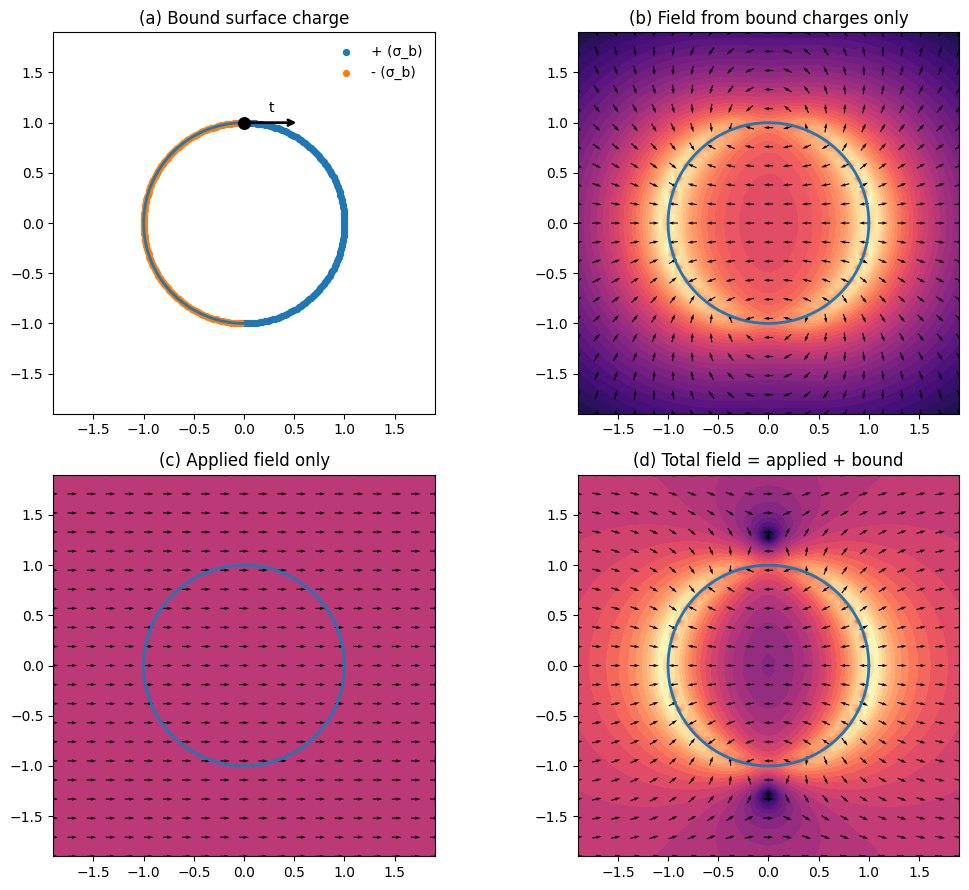

In [15]:
# ==========================================================
# STUDENTS: READ THIS CELL TOP-TO-BOTTOM
#
# Circular dielectric slice. We build ONLY bound surface charge using:
#   sigma_b = P · n
# where n is the outward normal to the circle.
#
# Then:
#   E_total = E_applied + E_from_bound_charges
#
# MAIN KNOBS:
#   E_app (line 24)
#   alpha (line 30)
# ==========================================================

# -----------------------------
# 1) Geometry
# -----------------------------
R = 1.0

# -----------------------------
# 2) Applied electric field (students change this)
# -----------------------------
# Try: (1,0), (0,1), (1,1)
E_app = np.array([1.0, 0.0], dtype=float)

# -----------------------------
# 3) Simple polarization model
# -----------------------------
alpha = 0.5
P_vec = alpha * E_app

# -----------------------------
# 4) Create bound charges from sigma_b = P · n
# -----------------------------
n_boundary = 240
t_bdry, charges_pos, charges_q = bound_surface_charges_from_P_circle(
    R=R, P_vec=P_vec, npts=n_boundary
)

# -----------------------------
# 5) Field grid + numerical settings
# -----------------------------
pad = 0.9
xmin, xmax = -R - pad, R + pad
ymin, ymax = -R - pad, R + pad

nx, ny = 61, 61
softening = 0.05
eps = 1e-12

X, Y, eval_pts = make_field_grid(xmin, xmax, ymin, ymax, nx=nx, ny=ny)

# Quiver settings (less dense, smaller arrows)
skip = 3
qscale = 40

# Color scheme
cmap = "magma"

# ==========================================================
# Compute fields
# ==========================================================

# (b) bound-charge field
Ex_b, Ey_b = electric_field_from_point_charges(
    eval_pts, charges_pos, charges_q, softening=softening
)

# (c) applied field (uniform)
Ex_app = np.full_like(Ex_b, E_app[0])
Ey_app = np.full_like(Ey_b, E_app[1])

# (d) total
Ex_tot = Ex_b + Ex_app
Ey_tot = Ey_b + Ey_app

# reshape for plotting
Ex_b = Ex_b.reshape(X.shape);  Ey_b = Ey_b.reshape(Y.shape)
Ex_app = Ex_app.reshape(X.shape); Ey_app = Ey_app.reshape(Y.shape)
Ex_tot = Ex_tot.reshape(X.shape); Ey_tot = Ey_tot.reshape(Y.shape)

# magnitudes (for contour)
E_b_mag = np.sqrt(Ex_b**2 + Ey_b**2)
E_app_mag = np.sqrt(Ex_app**2 + Ey_app**2)
E_tot_mag = np.sqrt(Ex_tot**2 + Ey_tot**2)

# unit vectors for quiver
Ub_x = Ex_b / (E_b_mag + eps);     Ub_y = Ey_b / (E_b_mag + eps)
Ua_x = Ex_app / (E_app_mag + eps); Ua_y = Ey_app / (E_app_mag + eps)
Ut_x = Ex_tot / (E_tot_mag + eps); Ut_y = Ey_tot / (E_tot_mag + eps)

# ==========================================================
# Common color scale across the three field panels
# ==========================================================
logEb = np.log10(E_b_mag + eps)
logEa = np.log10(E_app_mag + eps)
logEt = np.log10(E_tot_mag + eps)

vmin = min(logEb.min(), logEa.min(), logEt.min())
vmax = max(logEb.max(), logEa.max(), logEt.max())

# ==========================================================
# Four-panel figure
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
(axA, axB), (axC, axD) = axes

# ---- (a) Bound charges on the circle ----
ang = np.linspace(0, 2*np.pi, 400)
axA.plot(R*np.cos(ang), R*np.sin(ang), linewidth=2)

plus = charges_q > 0
minus = charges_q < 0
axA.scatter(charges_pos[plus, 0],  charges_pos[plus, 1],  s=18, label="+ (σ_b)")
axA.scatter(charges_pos[minus, 0], charges_pos[minus, 1], s=18, label="- (σ_b)")

# Mark t=0 at 12 o'clock and +t direction (clockwise)
t0_x, t0_y = 0.0, R
axA.scatter([t0_x], [t0_y], s=70, zorder=5, color="black")
arrow_len = 0.55 * R
axA.annotate("", xy=(t0_x + arrow_len, t0_y), xytext=(t0_x, t0_y),
             arrowprops=dict(arrowstyle="->", linewidth=2))
axA.text(t0_x + 0.5*arrow_len, t0_y + 0.08*R, "t", ha="center", va="bottom")

axA.set_aspect("equal", "box")
axA.set_xlim(xmin, xmax)
axA.set_ylim(ymin, ymax)
axA.set_title("(a) Bound surface charge")
axA.legend(frameon=False, loc="upper right")

# ---- (b) Field from bound charges only ----
contB = axB.contourf(X, Y, logEb, levels=30, cmap=cmap, vmin=vmin, vmax=vmax)
axB.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           Ub_x[::skip, ::skip], Ub_y[::skip, ::skip],
           pivot="middle", scale=qscale)
axB.plot(R*np.cos(ang), R*np.sin(ang), linewidth=2)
axB.set_aspect("equal", "box")
axB.set_xlim(xmin, xmax)
axB.set_ylim(ymin, ymax)
axB.set_title("(b) Field from bound charges only")

# ---- (c) Applied field only ----
contC = axC.contourf(X, Y, logEa, levels=30, cmap=cmap, vmin=vmin, vmax=vmax)
axC.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           Ua_x[::skip, ::skip], Ua_y[::skip, ::skip],
           pivot="middle", scale=qscale)
axC.plot(R*np.cos(ang), R*np.sin(ang), linewidth=2)
axC.set_aspect("equal", "box")
axC.set_xlim(xmin, xmax)
axC.set_ylim(ymin, ymax)
axC.set_title("(c) Applied field only")

# ---- (d) Total field ----
contD = axD.contourf(X, Y, logEt, levels=30, cmap=cmap, vmin=vmin, vmax=vmax)
axD.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           Ut_x[::skip, ::skip], Ut_y[::skip, ::skip],
           pivot="middle", scale=qscale)
axD.plot(R*np.cos(ang), R*np.sin(ang), linewidth=2)
axD.set_aspect("equal", "box")
axD.set_xlim(xmin, xmax)
axD.set_ylim(ymin, ymax)
axD.set_title("(d) Total field = applied + bound")

plt.tight_layout()
plt.show()